# 🚀 ViBERT Sentiment Training (Google Colab T4)
**Model:** `dekanonymous/vibert-sentiment-analysis` (base: BERT trained on Vietnamese)

Dataset format:
- `sentences` (text)
- `sentiment` (label: negative / neutral / positive)

In [1]:
# ✅ Kiểm tra GPU
!nvidia-smi

Thu Apr 23 18:55:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ✅ Cài thư viện
!pip install -q transformers datasets accelerate scikit-learn

In [3]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Load & Preprocess Data

In [4]:
# LOAD DATA
train_df = pd.read_csv('/content/train.csv')
val_df   = pd.read_csv('/content/val.csv')
test_df  = pd.read_csv('/content/test.csv')

# RENAME COLUMNS
for df in [train_df, val_df, test_df]:
    df.rename(columns={'sentences': 'text'}, inplace=True)

# ENCODE LABEL
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
for df in [train_df, val_df, test_df]:
    df['label'] = df['sentiment'].map(label_map)

train_df = train_df[['text', 'label']]
val_df   = val_df[['text', 'label']]
test_df  = test_df[['text', 'label']]

print('Train size:', len(train_df))
print('Val size  :', len(val_df))
print('Test size :', len(test_df))
print()
print('Label distribution (train):')
print(train_df['label'].value_counts())
train_df.head()

Train size: 22921
Val size  : 2865
Test size : 2866

Label distribution (train):
label
0    8650
2    8097
1    6174
Name: count, dtype: int64


,text,label
0,giải thích bài giảng khá chi tiết.,2
1,em rất muốn học thầy vào kỳ sau.,2
2,"mọa, mình nhà thanh hóa mà đéo biết gì luôn @@...",0
3,shop lừa đảo mà còn làm ngơ,1
4,"không khí vui vẻ, thoải mái.",2


## 2. Tokenize

In [6]:
# ⚠️ Uncomment dòng bạn muốn dùng:
# MODEL_NAME = 'FPTAI/vibert-base-cased'       # ViBERT chính thức của FPT AI
# MODEL_NAME = 'uitnlp/visobert'               # ViSoBERT (tốt cho mạng xã hội)
MODEL_NAME = 'FPTAI/vibert-base-cased'

print('Đang dùng model:', MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 200  # Có thể tăng lên 256 nếu câu dài, nhưng sẽ tốn VRAM hơn

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

cols = ['input_ids', 'attention_mask', 'token_type_ids', 'label']
# ViBERT (BERT-based) có token_type_ids; lọc cột tồn tại thực tế
avail_cols = [c for c in cols if c in train_ds.column_names]
print('Columns used:', avail_cols)

train_ds.set_format(type='torch', columns=avail_cols)
val_ds.set_format(type='torch', columns=avail_cols)
test_ds.set_format(type='torch', columns=avail_cols)

Đang dùng model: FPTAI/vibert-base-cased


Map:   0%|          | 0/22921 [00:00<?, ? examples/s]

Map:   0%|          | 0/2865 [00:00<?, ? examples/s]

Map:   0%|          | 0/2866 [00:00<?, ? examples/s]

Columns used: ['input_ids', 'attention_mask', 'token_type_ids', 'label']


## 3. Model & Class Weights

In [7]:
# MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True  # an toàn khi load head mới
)

# CLASS WEIGHTS — xử lý mất cân bằng nhãn
weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label']
)
class_weights = torch.tensor(weights, dtype=torch.float).to('cuda')
print('Class weights:', class_weights)

def compute_loss(model, inputs, return_outputs=False, **kwargs):
    labels = inputs.get('labels')
    outputs = model(**inputs)
    logits = outputs.get('logits')
    loss = CrossEntropyLoss(weight=class_weights)(logits, labels)
    return (loss, outputs) if return_outputs else loss

pytorch_model.bin:   0%|          | 0.00/581M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/581M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: FPTAI/vibert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Class weights: tensor([0.8833, 1.2375, 0.9436], device='cuda:0')


## 4. Metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

## 5. Training Arguments

In [9]:
training_args = TrainingArguments(
    output_dir='./vibert_model',

    eval_strategy='epoch',
    save_strategy='epoch',

    learning_rate=2e-5,              # ViBERT (BERT-base) thường cần LR cao hơn PhoBERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=6,

    weight_decay=0.02,
    warmup_steps=200,                # Warm up cố định phù hợp T4

    lr_scheduler_type='cosine',

    load_best_model_at_end=True,
    metric_for_best_model='f1',

    fp16=True,                       # Bắt buộc bật với T4
    gradient_accumulation_steps=2,

    logging_steps=200,
    save_total_limit=2,

    report_to='none'
)

## 6. Train

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.compute_loss = compute_loss

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.645896,0.289740,0.893194,0.893344
2,0.459304,0.299008,0.897731,0.897445
3,0.307323,0.319515,0.907853,0.907821
4,0.179225,0.470872,0.894939,0.895147
5,0.112708,0.563351,0.900524,0.900694


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3585, training_loss=0.39295569171134065, metrics={'train_runtime': 1200.7426, 'train_samples_per_second': 114.534, 'train_steps_per_second': 3.583, 'total_flos': 1.1778950483874e+16, 'train_loss': 0.39295569171134065, 'epoch': 5.0})

## 7. Evaluate

In [11]:
print('=== Validation Set ===')
print(trainer.evaluate())

print('\n=== Test Set ===')
print(trainer.evaluate(test_ds))

=== Validation Set ===


{'eval_loss': 0.32055041193962097, 'eval_accuracy': 0.9078534031413612, 'eval_f1': 0.9078206799568347, 'eval_runtime': 7.6924, 'eval_samples_per_second': 372.448, 'eval_steps_per_second': 23.4, 'epoch': 5.0}

=== Test Set ===
{'eval_loss': 0.35670211911201477, 'eval_accuracy': 0.8921842288904397, 'eval_f1': 0.8919698177196459, 'eval_runtime': 8.0455, 'eval_samples_per_second': 356.224, 'eval_steps_per_second': 22.373, 'epoch': 5.0}


## 8. Save Model

In [12]:
trainer.save_model('/content/vibert_best')
tokenizer.save_pretrained('/content/vibert_best')
print('✅ Model saved to /content/vibert_best')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to /content/vibert_best


## 9. Confusion Matrix

              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      1082
     neutral       0.86      0.84      0.85       772
    positive       0.90      0.92      0.91      1012

    accuracy                           0.89      2866
   macro avg       0.89      0.89      0.89      2866
weighted avg       0.89      0.89      0.89      2866



<Figure size 600x600 with 0 Axes>

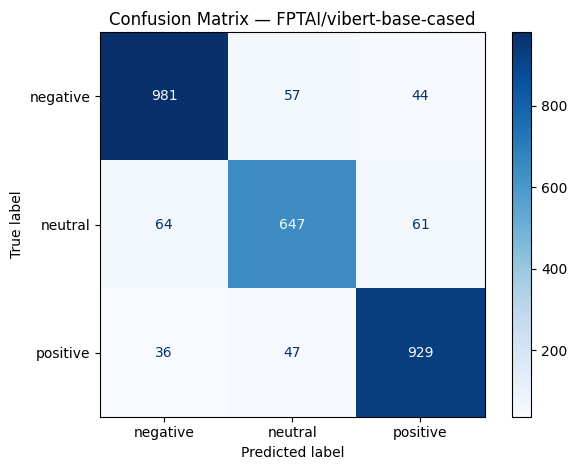

✅ Confusion matrix saved.


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

predictions = trainer.predict(test_ds)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Classification Report
print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — {MODEL_NAME}')
plt.tight_layout()
plt.savefig('/content/vibert_confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved.')